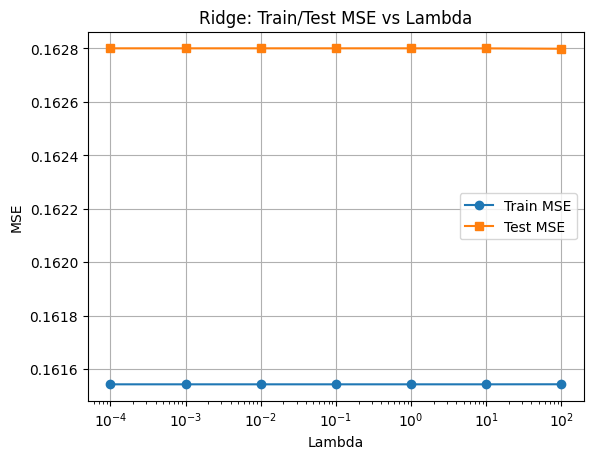

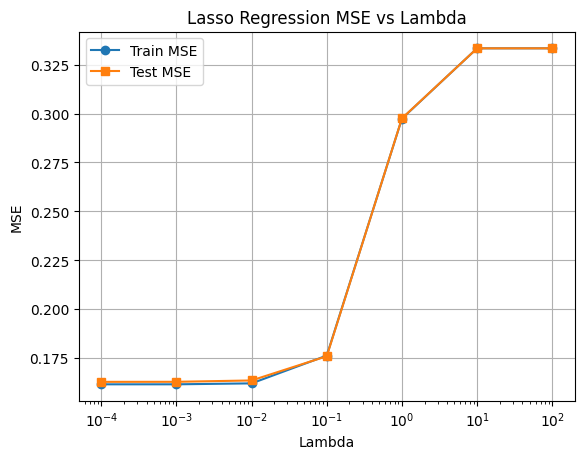

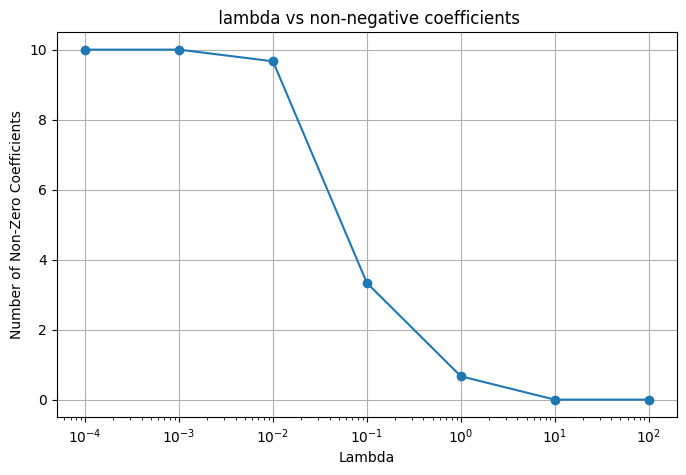

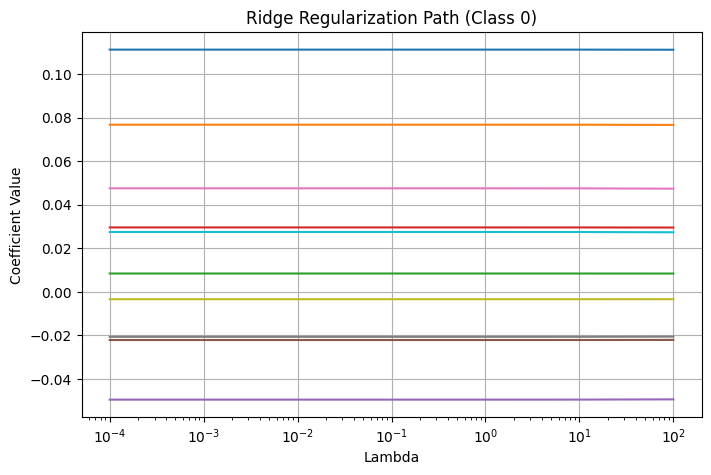

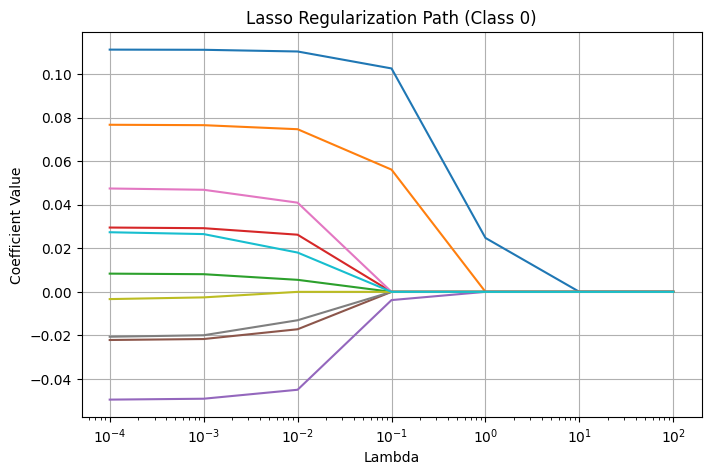

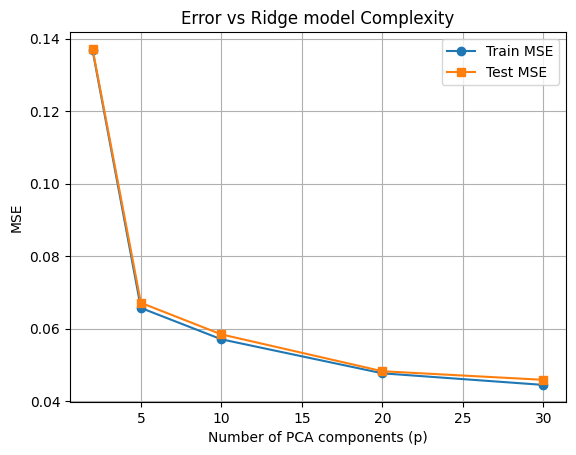

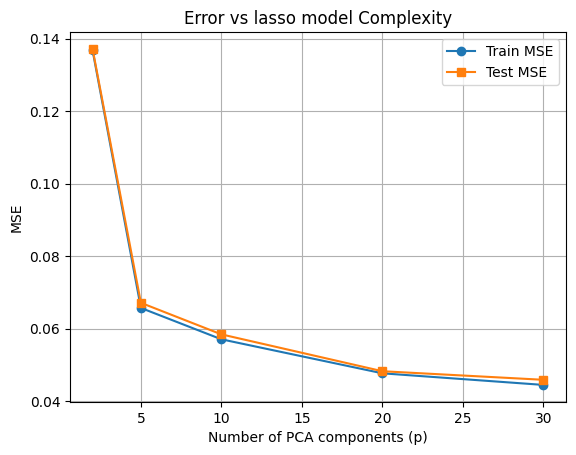

Best Ridge Lambda: 100.0
Ridge Test Accuracy: 95.13822688274547
Best Lasso Lambda: 0.0001
Lasso Test Accuracy: 95.13822688274547


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('mnist.npz')

x_train, y_train = data["x_train"], data["y_train"]
x_test, y_test = data["x_test"], data["y_test"]

mask = np.isin(y_train, [0, 1, 2])
x_train = x_train[mask]
y_train = y_train[mask]

mask = np.isin(y_test, [0, 1, 2])
x_test = x_test[mask]
y_test = y_test[mask]


x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)

x_train = x_train/255.0
x_train_original = x_train.copy()
x_test = x_test/255.0
x_test_original = x_test.copy()

mean = np.mean(x_train, axis=0)
x_train = x_train - mean
x_test = x_test - mean
s = (x_train.T @ x_train)/(x_train.shape[0]-1)

def PCA(s, p, x_train, x_test):

    eigonvalues, eigenvectors = np.linalg.eigh(s)
    idx = np.argsort(eigonvalues)[::-1]
    eigonvalues = eigonvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    Up = eigenvectors[:, :p]

    x_train_p = x_train @ Up
    x_test_p = x_test @ Up

    return x_train_p, x_test_p



# print(y_train)
x_train, x_test = PCA(s, 10, x_train, x_test);
y0 = (y_train==0).astype(int)
y1 = (y_train==1).astype(int)
y2 = (y_train==2).astype(int)

y0_test = (y_test==0).astype(int)
y1_test = (y_test==1).astype(int)
y2_test = (y_test==2).astype(int)

lamdas = np.array([1/10000, 1/1000, 1/100, 1/10, 1, 10, 100])

train_errors = []
test_errors = []
ridge_paths = []

for lamda in lamdas:
    w0 = np.linalg.inv(x_train.T @ x_train + lamda*np.eye(x_train.shape[1])) @ x_train.T @ y0
    w1 = np.linalg.inv(x_train.T @ x_train + lamda*np.eye(x_train.shape[1])) @ x_train.T @ y1
    w2 = np.linalg.inv(x_train.T @ x_train + lamda*np.eye(x_train.shape[1])) @ x_train.T @ y2
    ridge_paths.append(w0)

    pred_train0 = x_train @ w0
    pred_train1 = x_train @ w1
    pred_train2 = x_train @ w2
    # print(pred_train0)
    # print(pred_train1)
    # print(pred_train2)


    pred_test0 = x_test @ w0
    pred_test1 = x_test @ w1
    pred_test2 = x_test @ w2
    # print(pred_test0)
    # print(pred_test1)
    # print(pred_test2)

    train_mse = (np.mean((pred_train0 - y0) ** 2) + np.mean((pred_train1 - y1) ** 2) + np.mean((pred_train2 - y2) ** 2)) / 3
    test_mse = (np.mean((pred_test0 - y0_test) ** 2) + np.mean((pred_test1 - y1_test) ** 2) + np.mean((pred_test2 - y2_test) ** 2)) / 3

    train_errors.append(train_mse)
    test_errors.append(test_mse)

best_ridge_lambda = lamdas[np.argmin(test_errors)]

plt.plot(lamdas, train_errors, marker='o', label='Train MSE')
plt.plot(lamdas, test_errors, marker='s', label='Test MSE')

plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Ridge: Train/Test MSE vs Lambda")
plt.legend()
plt.grid(True)
plt.show()


# lasso regression
from sklearn.linear_model import Lasso

lasso_train_mse = []
lasso_test_mse = []
non_zero_counts = []
lasso_paths = []

for lamda in lamdas:

    model0 = Lasso(alpha=lamda, fit_intercept=False, max_iter=10000)
    model1 = Lasso(alpha=lamda, fit_intercept=False, max_iter=10000)
    model2 = Lasso(alpha=lamda, fit_intercept=False, max_iter=10000)

    model0.fit(x_train, y0)
    model1.fit(x_train, y1)
    model2.fit(x_train, y2)

    w0 = model0.coef_
    w1 = model1.coef_
    w2 = model2.coef_

    lasso_paths.append(w0)

    count0 = np.sum(w0 != 0)
    count1 = np.sum(w1 != 0)
    count2 = np.sum(w2 != 0)

    avg = (count0 + count1 + count2) / 3
    non_zero_counts.append(avg)

    pred_train0 = x_train @ w0
    pred_train1 = x_train @ w1
    pred_train2 = x_train @ w2

    pred_test0 = x_test @ w0
    pred_test1 = x_test @ w1
    pred_test2 = x_test @ w2

    train_mse = (np.mean((pred_train0 - y0) ** 2) +np.mean((pred_train1 - y1) ** 2) +np.mean((pred_train2 - y2) ** 2))/3
    test_mse = (np.mean((pred_test0 - y0_test) ** 2) +np.mean((pred_test1 - y1_test) ** 2) +np.mean((pred_test2 - y2_test) ** 2))/3

    lasso_train_mse.append(train_mse)
    lasso_test_mse.append(test_mse)

best_lasso_lambda = lamdas[np.argmin(lasso_test_mse)]

plt.plot(lamdas, lasso_train_mse, marker='o', label='Train MSE')
plt.plot(lamdas, lasso_test_mse, marker='s', label='Test MSE')

plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Lasso Regression MSE vs Lambda")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(lamdas, non_zero_counts, marker='o')
plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Number of Non-Zero Coefficients")
plt.title(" lambda vs non-negative coefficients")
plt.grid(True)
plt.show()


ridge_paths = np.array(ridge_paths)
plt.figure(figsize=(8,5))

for i in range(x_train.shape[1]):
    plt.plot(lamdas, ridge_paths[:, i])

plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regularization Path (Class 0)")
plt.grid(True)
plt.show()


lasso_paths = np.array(lasso_paths)
plt.figure(figsize=(8,5))

for i in range(x_train.shape[1]):
    plt.plot(lamdas, lasso_paths[:, i])

plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regularization Path (Class 0)")
plt.grid(True)
plt.show()


p_values = [2, 5, 10, 20, 30]
train_errors = []
test_errors = []

for p in p_values:
    s = (x_train_original.T @ x_train_original)/(x_train_original.shape[0]-1)
    x_train_p, x_test_p = PCA(s, p, x_train_original, x_test_original)

    w0 = np.linalg.inv(x_train_p.T @ x_train_p + best_ridge_lambda*np.eye(x_train_p.shape[1])) @ x_train_p.T @ y0
    w1 = np.linalg.inv(x_train_p.T @ x_train_p + best_ridge_lambda*np.eye(x_train_p.shape[1])) @ x_train_p.T @ y1
    w2 = np.linalg.inv(x_train_p.T @ x_train_p + best_ridge_lambda*np.eye(x_train_p.shape[1])) @ x_train_p.T @ y2

    pred_train0 = x_train_p @ w0
    pred_train1 = x_train_p @ w1
    pred_train2 = x_train_p @ w2

    pred_test0 = x_test_p @ w0
    pred_test1 = x_test_p @ w1
    pred_test2 = x_test_p @ w2

    train_errors_p = (np.mean((pred_train0 - y0) ** 2) +np.mean((pred_train1 - y1) ** 2) +np.mean((pred_train2 - y2) ** 2)) / 3

    test_errors_p = (np.mean((pred_test0 - y0_test) ** 2) +np.mean((pred_test1 - y1_test) ** 2) +np.mean((pred_test2 - y2_test) ** 2)) / 3

    train_errors.append(train_errors_p)
    test_errors.append(test_errors_p)

plt.plot(p_values, train_errors, marker='o', label='Train MSE')
plt.plot(p_values, test_errors, marker='s', label='Test MSE')

plt.xlabel("Number of PCA components (p)")
plt.ylabel("MSE")
plt.title("Error vs Ridge model Complexity")
plt.legend()
plt.grid(True)
plt.show()

train_errors = []
test_errors = []
for p in p_values:
    s = (x_train_original.T @ x_train_original)/(x_train_original.shape[0]-1)
    x_train_p, x_test_p = PCA(s, p, x_train_original, x_test_original)


    model0 = Lasso(alpha=best_lasso_lambda, fit_intercept=False, max_iter=10000)
    model1 = Lasso(alpha=best_lasso_lambda, fit_intercept=False, max_iter=10000)
    model2 = Lasso(alpha=best_lasso_lambda, fit_intercept=False, max_iter=10000)

    model0.fit(x_train_p, y0)
    model1.fit(x_train_p, y1)
    model2.fit(x_train_p, y2)

    w0 = model0.coef_
    w1 = model1.coef_
    w2 = model2.coef_

    pred_train0 = x_train_p @ w0
    pred_train1 = x_train_p @ w1
    pred_train2 = x_train_p @ w2

    pred_test0 = x_test_p @ w0
    pred_test1 = x_test_p @ w1
    pred_test2 = x_test_p @ w2


    train_errors_p = (np.mean((pred_train0 - y0) ** 2) +np.mean((pred_train1 - y1) ** 2) +np.mean((pred_train2 - y2) ** 2)) / 3

    test_errors_p = (np.mean((pred_test0 - y0_test) ** 2) +np.mean((pred_test1 - y1_test) ** 2) +np.mean((pred_test2 - y2_test) ** 2)) / 3

    train_errors.append(train_errors_p)
    test_errors.append(test_errors_p)

plt.plot(p_values, train_errors, marker='o', label='Train MSE')
plt.plot(p_values, test_errors, marker='s', label='Test MSE')

plt.xlabel("Number of PCA components (p)")
plt.ylabel("MSE")
plt.title("Error vs lasso model Complexity")
plt.legend()
plt.grid(True)
plt.show()


#Accuracy comparison

w0 = np.linalg.inv(x_train.T @ x_train + best_ridge_lambda*np.eye(x_train.shape[1])) @ x_train.T @ y0
w1 = np.linalg.inv(x_train.T @ x_train + best_ridge_lambda*np.eye(x_train.shape[1])) @ x_train.T @ y1
w2 = np.linalg.inv(x_train.T @ x_train + best_ridge_lambda*np.eye(x_train.shape[1])) @ x_train.T @ y2

pred0 = x_test @ w0
pred1 = x_test @ w1
pred2 = x_test @ w2

scores = np.array([pred0, pred1, pred2])
ridge_pred = np.argmax(scores, axis=0)

ridge_accuracy = np.mean(ridge_pred == y_test) * 100
print("Best Ridge Lambda:", best_ridge_lambda)
print("Ridge Test Accuracy:", ridge_accuracy)


model0 = Lasso(alpha=best_lasso_lambda, fit_intercept=False, max_iter=10000)
model1 = Lasso(alpha=best_lasso_lambda, fit_intercept=False, max_iter=10000)
model2 = Lasso(alpha=best_lasso_lambda, fit_intercept=False, max_iter=10000)

model0.fit(x_train, y0)
model1.fit(x_train, y1)
model2.fit(x_train, y2)

pred0 = x_test @ model0.coef_
pred1 = x_test @ model1.coef_
pred2 = x_test @ model2.coef_

scores = np.array([pred0, pred1, pred2])
lasso_pred = np.argmax(scores, axis=0)

lasso_accuracy = np.mean(lasso_pred == y_test) * 100
print("Best Lasso Lambda:", best_lasso_lambda)
print("Lasso Test Accuracy:", lasso_accuracy)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('mnist.npz')

x_train, y_train = data["x_train"], data["y_train"]
x_test, y_test = data["x_test"], data["y_test"]

mask = np.isin(y_train, [0, 1, 2])
x_train = x_train[mask]
y_train = y_train[mask]

mask = np.isin(y_test, [0, 1, 2])
x_test = x_test[mask]
y_test = y_test[mask]


x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)

x_train = x_train/255.0
x_train_original = x_train.copy()
x_test = x_test/255.0
x_test_original = x_test.copy()

mean = np.mean(x_train, axis=0)
x_train = x_train - mean
x_test = x_test - mean
s = (x_train.T @ x_train)/(x_train.shape[0]-1)

def PCA(s, p, x_train, x_test):

    eigonvalues, eigenvectors = np.linalg.eigh(s)
    idx = np.argsort(eigonvalues)[::-1]
    eigonvalues = eigonvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    Up = eigenvectors[:, :p]

    x_train_p = x_train @ Up
    x_test_p = x_test @ Up

    return x_train_p, x_test_p



# print(y_train)
x_train, x_test = PCA(s, 10, x_train, x_test);


def gini(y):
    impurity = 1.0

    for c in range(3):
        pk = np.sum(y == c) / len(y)
        impurity -= pk ** 2

    return impurity


def best_split(X, y):
    best_feature = None
    best_threshold = None
    best_gini = float('inf')

    for feature in range(X.shape[1]):
        values = np.sort(np.unique(X[:, feature]))
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = X[:, feature] > threshold

            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            y_l = y[left_mask]
            y_r = y[right_mask]

            wg = (len(y_l)/len(y))*gini(y_l) + (len(y_r)/len(y))*gini(y_r)

            if wg < best_gini:
                best_gini = wg
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gini


root_feature, root_threshold, root_gini = best_split(x_train, y_train)

print("Best Feature:", root_feature)
print("Best Threshold:", root_threshold)
print("Best Gini:", root_gini)
print()

left_mask = x_train[:, root_feature] <= root_threshold
right_mask = x_train[:, root_feature] > root_threshold

X_left = x_train[left_mask]
y_left = y_train[left_mask]

X_right = x_train[right_mask]
y_right = y_train[right_mask]

best_feature_left, best_threshold_left, best_gini_left = best_split(X_left, y_left)
print("Best split in LEFT child")
print("Feature:", best_feature_left)
print("Threshold:", best_threshold_left)
print("WG:", best_gini_left)

best_feature_right, best_threshold_right, best_gini_right = best_split(X_right, y_right)
print("Best split in RIGHT child")
print("Feature:", best_feature_right)
print("Threshold:", best_threshold_right)
print("WG:", best_gini_right)


if best_gini_left < best_gini_right:
    second_node = "LEFT"
    second_feature = best_feature_left
    second_threshold = best_threshold_left
else:
    second_node = "RIGHT"
    second_feature = best_feature_right
    second_threshold = best_threshold_right

print()
print("Second split chosen on:", second_node)
print("Feature:", second_feature)
print("Threshold:", second_threshold)
print()


def majority_class(y):
    values, counts = np.unique(y, return_counts=True)
    return values[np.argmax(counts)]



if second_node == "LEFT":
    left_left_mask = X_left[:, second_feature] <= second_threshold
    left_right_mask = X_left[:, second_feature] > second_threshold

    y_leaf1 = y_left[left_left_mask]
    y_leaf2 = y_left[left_right_mask]
    y_leaf3 = y_right

else:
    right_left_mask = X_right[:, second_feature] <= second_threshold
    right_right_mask = X_right[:, second_feature] > second_threshold

    y_leaf1 = y_left
    y_leaf2 = y_right[right_left_mask]
    y_leaf3 = y_right[right_right_mask]

leaf1_label = majority_class(y_leaf1)
leaf2_label = majority_class(y_leaf2)
leaf3_label = majority_class(y_leaf3)

def predict_sample(x):
    if x[root_feature] <= root_threshold:

        if second_node == "LEFT":
            if x[second_feature] <= second_threshold:
                return leaf1_label
            else:
                return leaf2_label
        else:
            return leaf1_label

    else:
        if second_node == "RIGHT":
            if x[second_feature] <= second_threshold:
                return leaf2_label
            else:
                return leaf3_label
        else:
            return leaf3_label

y_pred = np.array([predict_sample(x) for x in x_test])
overall_accuracy = np.mean(y_pred == y_test)
print("Overall Test Accuracy:", overall_accuracy)
print()


for c in [0, 1, 2]:
    class_mask = y_test == c
    class_acc = np.mean(y_pred[class_mask] == y_test[class_mask])
    print(f"Class {c} Accuracy:", class_acc)

print()


def build_tree(X, y):
    root_feature, root_threshold, root_gini = best_split(X, y)

    left_mask = X[:, root_feature] <= root_threshold
    right_mask = X[:, root_feature] > root_threshold

    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]

    f_left, t_left, g_left = best_split(X_left, y_left)
    f_right, t_right, g_right = best_split(X_right, y_right)

    if g_left < g_right:
        second_node = "LEFT"
        second_feature = f_left
        second_threshold = t_left

        ll_mask = X_left[:, second_feature] <= second_threshold
        lr_mask = X_left[:, second_feature] > second_threshold

        leaf1 = majority_class(y_left[ll_mask])
        leaf2 = majority_class(y_left[lr_mask])
        leaf3 = majority_class(y_right)

    else:
        second_node = "RIGHT"
        second_feature = f_right
        second_threshold = t_right

        rl_mask = X_right[:, second_feature] <= second_threshold
        rr_mask = X_right[:, second_feature] > second_threshold

        leaf1 = majority_class(y_left)
        leaf2 = majority_class(y_right[rl_mask])
        leaf3 = majority_class(y_right[rr_mask])

    return {
        "root_feature": root_feature,
        "root_threshold": root_threshold,
        "second_node": second_node,
        "second_feature": second_feature,
        "second_threshold": second_threshold,
        "leaf1": leaf1,
        "leaf2": leaf2,
        "leaf3": leaf3
    }


def predict_sample(tree, x):
    rf = tree["root_feature"]
    rt = tree["root_threshold"]
    sn = tree["second_node"]
    sf = tree["second_feature"]
    st = tree["second_threshold"]

    if x[rf] <= rt:
        if sn == "LEFT":
            if x[sf] <= st:
                return tree["leaf1"]
            else:
                return tree["leaf2"]
        else:
            return tree["leaf1"]
    else:
        if sn == "RIGHT":
            if x[sf] <= st:
                return tree["leaf2"]
            else:
                return tree["leaf3"]
        else:
            return tree["leaf3"]

def best_split_rf(X, y, k):
    best_feature = None
    best_threshold = None
    best_gini = float('inf')

    # randomly choose k features out of p
    selected_features = np.random.choice(X.shape[1], size=k, replace=False)

    for feature in selected_features:
        values = np.sort(np.unique(X[:, feature]))

        if len(values) < 2:
            continue

        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = X[:, feature] > threshold

            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            y_left = y[left_mask]
            y_right = y[right_mask]

            wg = (len(y_left)/len(y))*gini(y_left) + \
                 (len(y_right)/len(y))*gini(y_right)

            if wg < best_gini:
                best_gini = wg
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gini

def build_rf_tree(X, y, k):
    root_feature, root_threshold, root_gini = best_split_rf(X, y, k)

    left_mask = X[:, root_feature] <= root_threshold
    right_mask = X[:, root_feature] > root_threshold

    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]

    f_left, t_left, g_left = best_split_rf(X_left, y_left, k)
    f_right, t_right, g_right = best_split_rf(X_right, y_right, k)

    if g_left < g_right:
        second_node = "LEFT"
        second_feature = f_left
        second_threshold = t_left

        ll_mask = X_left[:, second_feature] <= second_threshold
        lr_mask = X_left[:, second_feature] > second_threshold

        leaf1 = majority_class(y_left[ll_mask])
        leaf2 = majority_class(y_left[lr_mask])
        leaf3 = majority_class(y_right)

    else:
        second_node = "RIGHT"
        second_feature = f_right
        second_threshold = t_right

        rl_mask = X_right[:, second_feature] <= second_threshold
        rr_mask = X_right[:, second_feature] > second_threshold

        leaf1 = majority_class(y_left)
        leaf2 = majority_class(y_right[rl_mask])
        leaf3 = majority_class(y_right[rr_mask])

    return {
        "root_feature": root_feature,
        "root_threshold": root_threshold,
        "second_node": second_node,
        "second_feature": second_feature,
        "second_threshold": second_threshold,
        "leaf1": leaf1,
        "leaf2": leaf2,
        "leaf3": leaf3
    }



oob_errors = []
oobs = []
trees = []
rf_trees = []
k = 3

for i in range(5):

    bootstrap_indices = np.random.choice(len(x_train), size=len(x_train),replace=True)

    x_boot = x_train[bootstrap_indices]
    y_boot = y_train[bootstrap_indices]

    rf_tree = build_rf_tree(x_boot, y_boot, k)
    rf_trees.append(rf_tree)

    all_indices = np.arange(len(x_train))
    oob_indices = np.setdiff1d(all_indices, bootstrap_indices)
    oobs.append(oob_indices)

    X_oob = x_train[oob_indices]
    y_oob = y_train[oob_indices]

    tree = build_tree(x_boot, y_boot)
    trees.append(tree)

    if len(X_oob) == 0:
        continue

    y_pred_oob = np.array([predict_sample(tree, x) for x in X_oob])

    oob_error = 1 - np.mean(y_pred_oob == y_oob)
    oob_errors.append(oob_error)

    print(f"Tree {i+1} OOB Error:", oob_error)


avg_oob_error = np.mean(oob_errors)
print("\nAverage OOB Error across 5 trees:", avg_oob_error)
print()

y_pred_test = []
for x in x_test:
    preds = [predict_sample(tree, x) for tree in trees]
    y_pred_test.append(majority_class(np.array(preds)))

y_pred_test = np.array(y_pred_test)
overall_acc = np.mean(y_pred_test == y_test)
print("Bagging Test Accuracy:", overall_acc)
print()

for c in [0, 1, 2]:
    mask = y_test == c
    class_acc = np.mean(y_pred_test[mask] == y_test[mask])
    print(f"Bagging Class {c} Accuracy:", class_acc)

print()


oob_votes = {i: [] for i in range(len(x_train))}
for tree_idx in range(5):
    rf_tree = rf_trees[tree_idx]
    oob_indices = oobs[tree_idx]

    for idx in oob_indices:
        pred = predict_sample(rf_tree, x_train[idx])
        oob_votes[idx].append(pred)

oob_pred = []
oob_true = []

for idx in range(len(x_train)):
    if len(oob_votes[idx]) == 0:
        continue

    pred = majority_class(np.array(oob_votes[idx]))
    oob_pred.append(pred)
    oob_true.append(y_train[idx])

oob_pred = np.array(oob_pred)
oob_true = np.array(oob_true)

rf_oob_error = 1 - np.mean(oob_pred == oob_true)

print("random forest OOB Error:", rf_oob_error)
print()

y_pred_rf = []
for x in x_test:
    preds = [predict_sample(tree, x) for tree in rf_trees]
    y_pred_rf.append(majority_class(np.array(preds)))

y_pred_rf = np.array(y_pred_rf)
print("Random Forest Test Accuracy:", np.mean(y_pred_rf == y_test))



Best Feature: 0
Best Threshold: -2.449737459618898
Best Gini: 0.37149902738162827

Best split in LEFT child
Feature: 2
Threshold: -0.852300176642882
WG: 0.04073990415101427
Best split in RIGHT child
Feature: 1
Threshold: -0.718837117915825
WG: 0.23681207706912116

Second split chosen on: LEFT
Feature: 2
Threshold: -0.852300176642882

Overall Test Accuracy: 0.6669844296155069

Class 0 Accuracy: 1.0
Class 1 Accuracy: 0.9462555066079296
Class 2 Accuracy: 0.0436046511627907

Tree 1 OOB Error: 0.3132722779473761
Tree 2 OOB Error: 0.32652465713451995
Tree 3 OOB Error: 0.3221398459078354
Tree 4 OOB Error: 0.32112634957688946
Tree 5 OOB Error: 0.333867677062081

Average OOB Error across 5 trees: 0.3233861615257404

Bagging Test Accuracy: 0.6768350810295519

Bagging Class 0 Accuracy: 1.0
Bagging Class 1 Accuracy: 0.9612334801762115
Bagging Class 2 Accuracy: 0.05717054263565891

random forest OOB Error: 0.32336827060505

Random Forest Test Accuracy: 0.7260883380997776


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Test MSE:  0.3629439763726561

Average OOB MSE:  0.3385971441280139



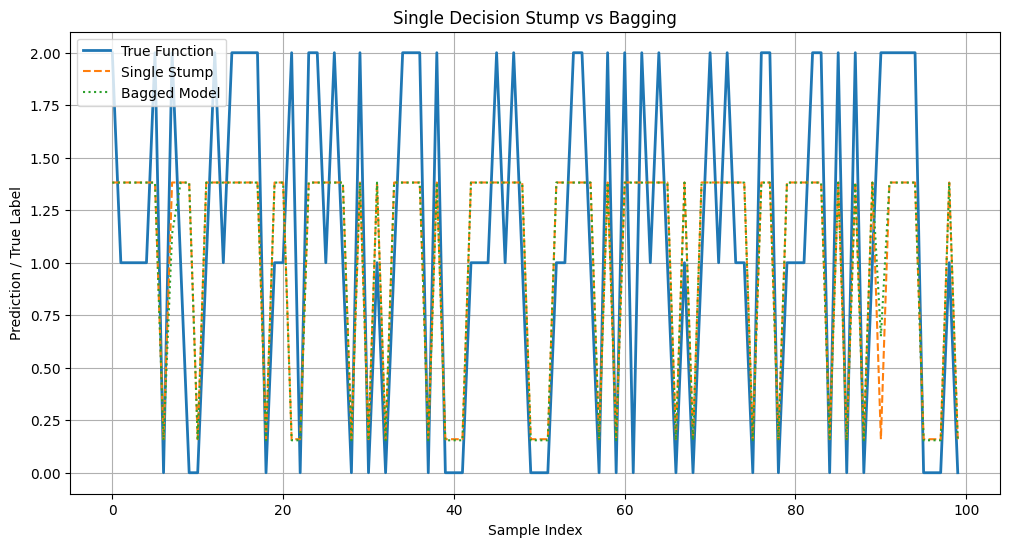

In [ ]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

train_mask = np.isin(y_train, [0, 1, 2])
test_mask = np.isin(y_test, [0, 1, 2])
12
x_train = x_train[train_mask]
y_train = y_train[train_mask]

x_test = x_test[test_mask]
y_test = y_test[test_mask]


x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0



mean = np.mean(x_train, axis=0)
x_train = x_train - mean
x_test = x_test - mean
s = (x_train.T @ x_train)/(x_train.shape[0]-1)

def PCA(s, p, x_train, x_test):

    eigonvalues, eigenvectors = np.linalg.eigh(s)
    idx = np.argsort(eigonvalues)[::-1]
    eigonvalues = eigonvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    Up = eigenvectors[:, :p]

    x_train_p = x_train @ Up
    x_test_p = x_test @ Up

    return x_train_p, x_test_p


x_train, x_test = PCA(s, 10, x_train, x_test)

def best_split_regression(X, y):
    best_feature = None
    best_threshold = None
    best_sse = float('inf')

    for feature in range(X.shape[1]):
        values = np.sort(np.unique(X[:, feature]))
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = X[:, feature] > threshold

            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            y_l = y[left_mask]
            y_r = y[right_mask]

            left_mean = np.mean(y_l)
            right_mean = np.mean(y_r)

            left_sse = np.sum((y_l - left_mean) ** 2)
            right_sse = np.sum((y_r - right_mean) ** 2)

            total_sse = left_sse + right_sse

            if total_sse < best_sse:
                best_sse = total_sse
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_sse


def h1(X, y):
    feature, threshold, _ = best_split_regression(X, y)

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    left_value = np.mean(y[left_mask])

    right_value = np.mean(y[right_mask])

    stump = {
        "feature": feature,
        "threshold": threshold,
        "left_value": left_value,
        "right_value": right_value
    }

    return stump


def predict_stump(X, stump):
    feature = stump["feature"]
    threshold = stump["threshold"]
    left_value = stump["left_value"]
    right_value = stump["right_value"]

    preds = np.where( X[:, feature] <= threshold, left_value, right_value )
    return preds


model = h1(x_train, y_train)
preds = predict_stump(x_test, model)
test_mse = np.mean((y_test-preds)**2)
print("Test MSE: ", test_mse)
print()


oobs = []
stumps = []
for i in range(5):

    bootstrap_indices = np.random.choice(len(x_train), size=len(x_train),replace=True)

    x_boot = x_train[bootstrap_indices]
    y_boot = y_train[bootstrap_indices]

    all_indices = np.arange(len(x_train))
    oob_indices = np.setdiff1d(all_indices, bootstrap_indices)
    oobs.append(oob_indices)

    X_oob = x_train[oob_indices]
    y_oob = y_train[oob_indices]

    model = h1(x_boot, y_boot)
    stumps.append(model)


oob_errors = []
for i in range(5):
    oob_indices = oobs[i]
    X_oob = x_train[oob_indices]
    y_oob = y_train[oob_indices]

    all_oob_preds = []
    for model in stumps:
        preds = predict_stump(X_oob, model)
        all_oob_preds.append(preds)

    all_oob_preds = np.array(all_oob_preds)
    all_oob_preds = np.mean(all_oob_preds, axis=0)

    oob_mse = np.mean((y_oob - all_oob_preds) ** 2)
    oob_errors.append(oob_mse)

avg = np.mean(oob_errors)
print("Average OOB MSE: ", avg)
print()


single_model = h1(x_train, y_train)
single_preds = predict_stump(x_test, single_model)

bagged_preds = []

for model in stumps:
    preds = predict_stump(x_test, model)
    bagged_preds.append(preds)

bagged_preds = np.array(bagged_preds)
bagged_preds = np.mean(bagged_preds, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label="True Function", linewidth=2)
plt.plot(single_preds[:100], label="Single Stump", linestyle="--")
plt.plot(bagged_preds[:100], label="Bagged Model", linestyle=":")

plt.xlabel("Sample Index")
plt.ylabel("Prediction / True Label")
plt.title("Single Decision Stump vs Bagging")
plt.legend()
plt.grid(True)
plt.show()
